# Fraud Detection - Classification Model (IndoBERT)

## Overview
- **Method**: IndoBERT Fine-tuning
- **Task**: 3-class classification (scam, not scam, neutral)

## Kelompok 14
- Rizqika Mulia Pratama (13522126)
- Auralea Alvinia Syaikha (13522148)
- Mohammad Akmal Ramadan (13522161)
---

## SECTION 1: Setup & Installation

In [1]:
!pip install transformers torch datasets scikit-learn pandas numpy matplotlib seaborn accelerate indoNLP -q

print('✓ Installation complete!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 8.6 MB/s eta 0:00:00
✓ Installation complete!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
import torch
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from indoNLP.preprocessing import replace_slang

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## SECTION 2: Load & Prepare Data

In [4]:
# Change the drive URL for the dataset
df = pd.read_csv('https://drive.google.com/uc?id=1S3JVoNk8DbudwnqCtojDy-ULAFBmYRhT')

print(f'Dataset loaded: {len(df):,} rows')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
df.head()

Dataset loaded: 1,503 rows

Label distribution:
label
neutral     520
not scam    495
scam        488
Name: count, dtype: int64


,text_id,text,text_cleaned,label
0,1,INFO RESMI: Selamat No.Anda terpilih pemenang ...,info resmi selamat nomor anda terpilih pemenan...,scam
1,2,"Yth. Nasabah, kartu ATM Anda terblokir karena ...",yang terhormat nasabah kartu atm anda terbloki...,scam
2,3,BUTUH DANA CPT? Ajukan pinjaman di KREDIT KILA...,butuh dana cepat ajukan pinjaman di kredit kil...,scam
3,4,"Mba, tlg isikan pulsa 50rb ke nomor ini dulu y...",mbak tolong isikan pulsa 50rb ke nomor ini dul...,scam
4,5,"Sdr/i, kami menemukan paket mencurigakan atas ...",saudara i kami menemukan paket mencurigakan at...,scam


### EDA

In [5]:
!pip install wordcloud -q

from wordcloud import WordCloud
from collections import Counter
import seaborn as sns

In [6]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def perform_comprehensive_eda(df):
    print('='*60)
    print('STARTING EXPLORATORY DATA ANALYSIS (EDA)')
    print('='*60)

    # --- 1. Label Distribution Visualization ---
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(x='label', data=df, palette='viridis', order=['not scam', 'neutral', 'scam'])
    plt.title('Label Distribution', fontsize=15)
    plt.xlabel('Label')
    plt.ylabel('Data Count')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    plt.show()

    # --- 2. Text Statistics (Feature Engineering for EDA) ---

    df['raw_char_count'] = df['text'].astype(str).apply(len)
    df['raw_word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
    df['avg_word_length'] = df['raw_char_count'] / df['raw_word_count']

    # fraud features
    df['caps_ratio'] = df['text'].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
    df['exclamation_count'] = df['text'].astype(str).apply(lambda x: x.count('!'))
    df['digit_count'] = df['text'].astype(str).apply(lambda x: sum(c.isdigit() for c in x))

    # --- 3. Visualization of Text Statistics ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Word Count Distribution
    sns.kdeplot(data=df, x='raw_word_count', hue='label', fill=True, palette='viridis', ax=axes[0, 0])
    axes[0, 0].set_title('Word Count per Text Distribution')
    axes[0, 0].set_xlim(0, 100)

    # Caps Lock Ratio
    sns.boxplot(x='label', y='caps_ratio', data=df, palette='viridis', ax=axes[0, 1], order=['not scam', 'neutral', 'scam'])
    axes[0, 1].set_title('Capital Ratio (Urgency Indicator)')

    # Exclamation Marks
    sns.barplot(x='label', y='exclamation_count', data=df, palette='viridis', ax=axes[1, 0], order=['not scam', 'neutral', 'scam'])
    axes[1, 0].set_title('Exclamation Marks Average (!)')

    # Digit Count (Seringkali fraud berisi banyak angka/nomor rekening/nominal)
    sns.boxplot(x='label', y='digit_count', data=df, palette='viridis', ax=axes[1, 1], order=['not scam', 'neutral', 'scam'])
    axes[1, 1].set_title('Number Count on Text')

    plt.tight_layout()
    plt.show()

    # --- 4. N-Gram Analysis (Semantic Content) ---

    def get_top_ngrams(corpus, n=1, top_k=10):
        vec = []
        for text in corpus:
            words = text.split()
            ngrams = zip(*[words[i:] for i in range(n)])
            vec.extend([" ".join(ngram) for ngram in ngrams])
        return Counter(vec).most_common(top_k)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    labels = ['scam', 'not scam', 'neutral']

    for i, label in enumerate(labels):
        subset = df[df['label'] == label]['text_cleaned']
        top_bigrams = get_top_ngrams(subset, n=2, top_k=10)
        x, y = zip(*top_bigrams) if top_bigrams else ([], [])

        sns.barplot(x=list(y), y=list(x), ax=axes[i], palette='viridis')
        axes[i].set_title(f'Top 10 Bigrams: {label.upper()}')
        axes[i].set_xlabel('Frequency')

    plt.tight_layout()
    plt.show()

    # --- 5. Word Clouds ---
    print("\nGenerating Word Clouds...")
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))

    for i, label in enumerate(labels):
        subset = df[df['label'] == label]['text_cleaned']
        text_combined = " ".join(subset.astype(str))

        if len(text_combined) > 0:
            wordcloud = WordCloud(width=800, height=800,
                                background_color='white',
                                colormap='viridis',
                                min_font_size=10).generate(text_combined)

            axes[i].imshow(wordcloud)
            axes[i].set_title(f'Word Cloud: {label.upper()}', fontsize=15)
            axes[i].axis("off")
        else:
            axes[i].text(0.5, 0.5, "No Data", ha='center')

    plt.tight_layout()
    plt.show()

STARTING EXPLORATORY DATA ANALYSIS (EDA)


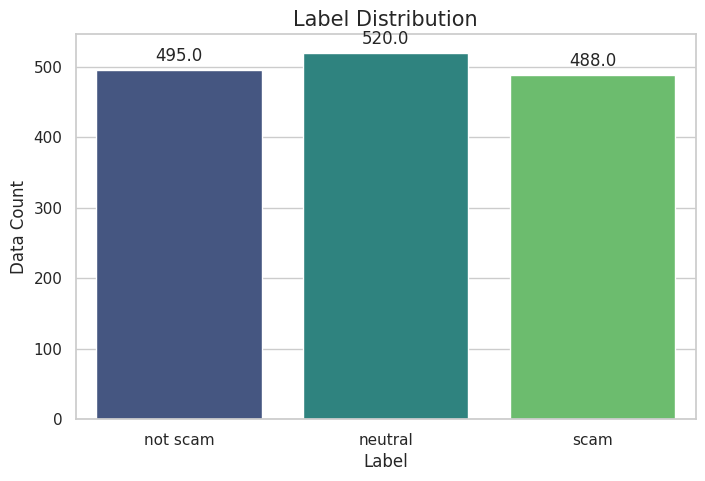

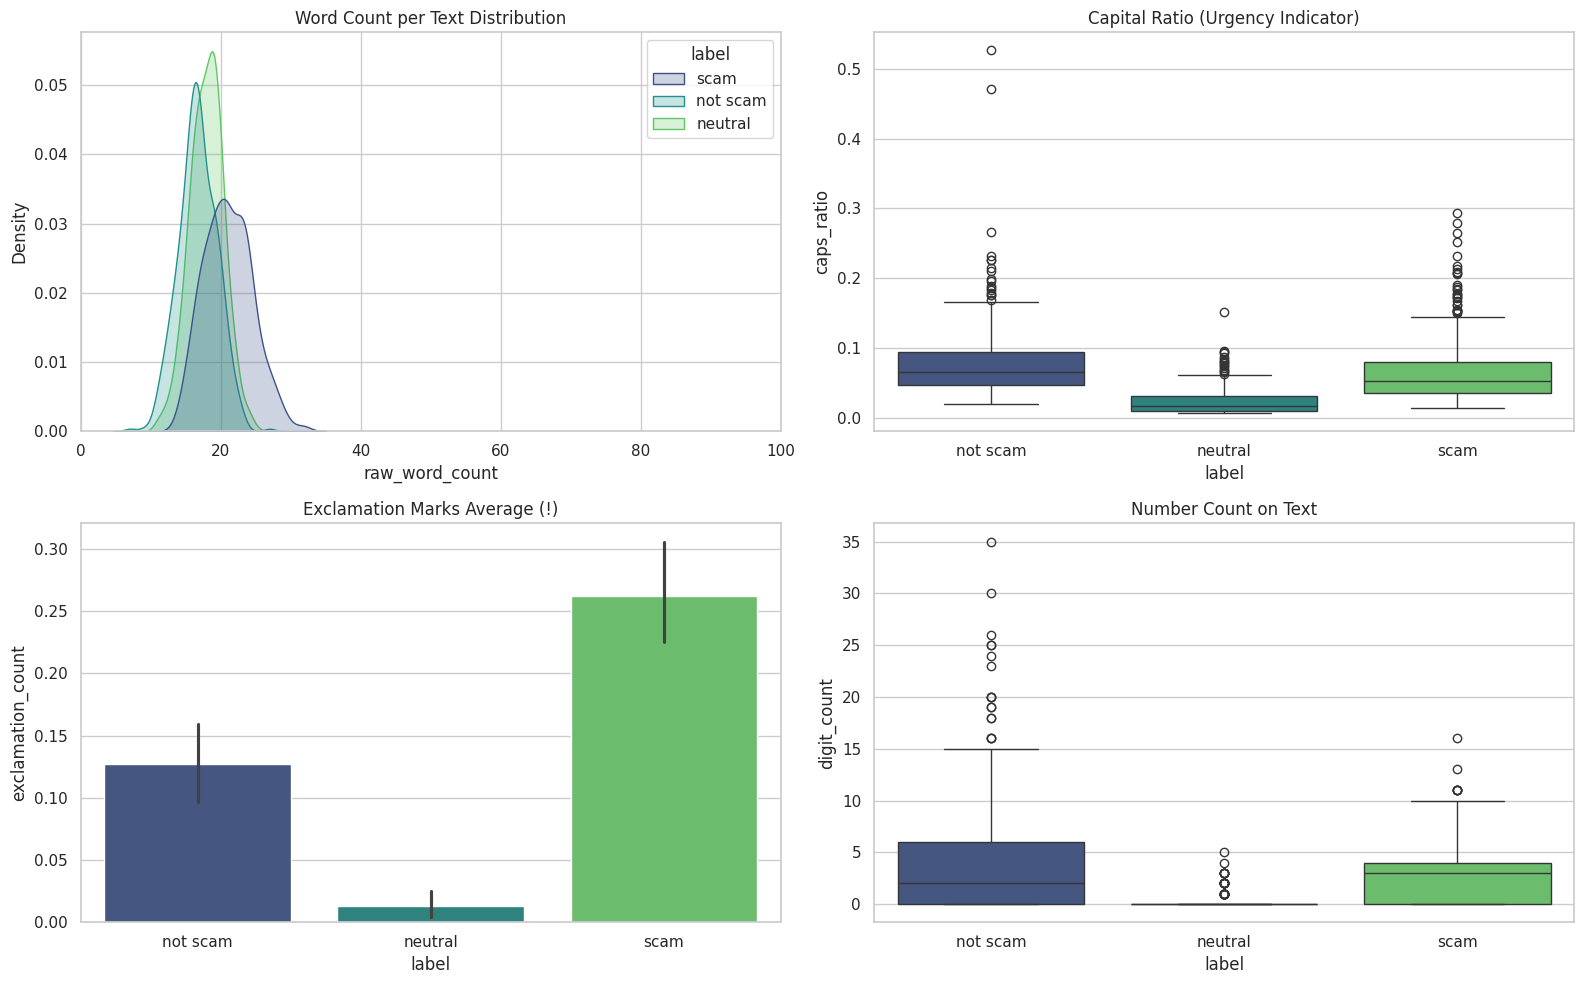

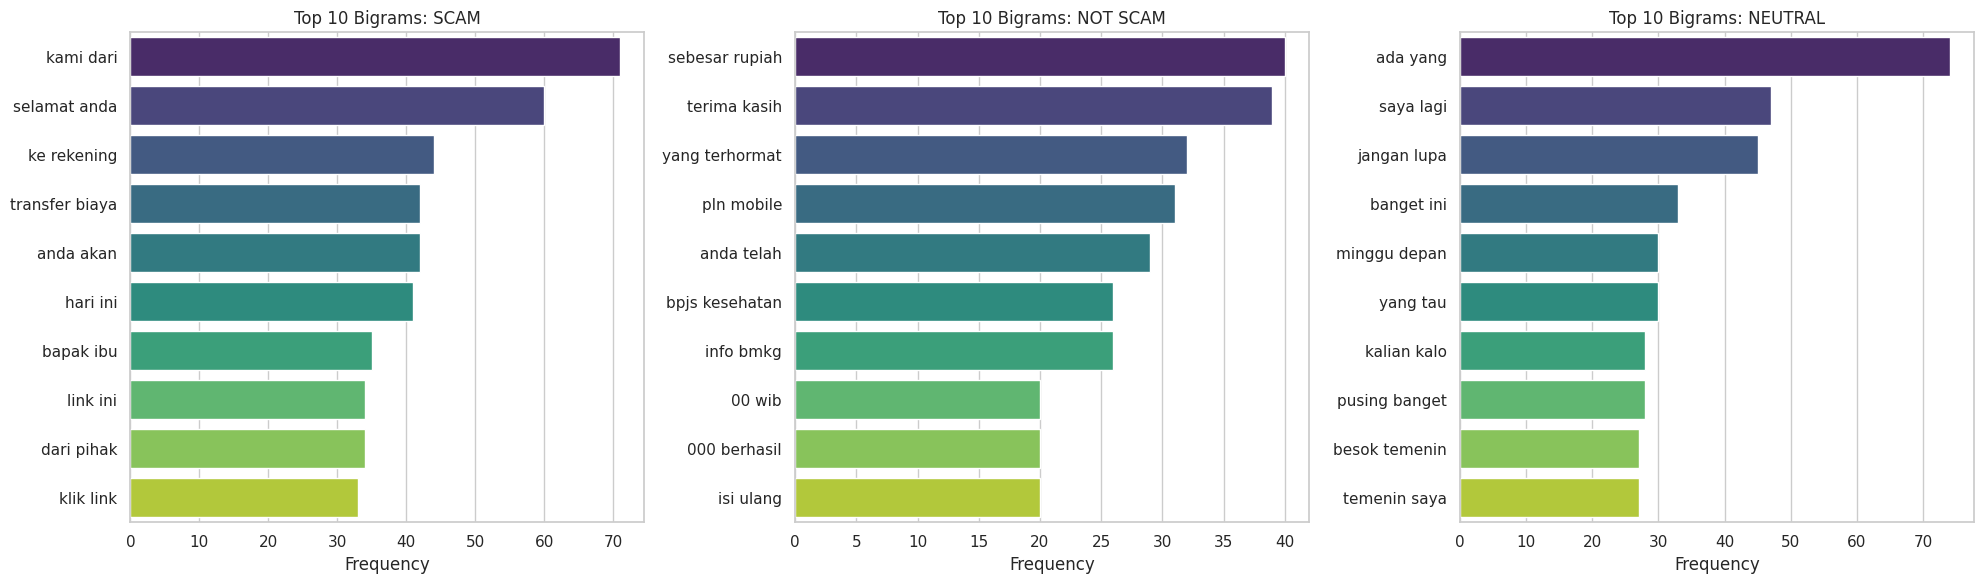


Generating Word Clouds...


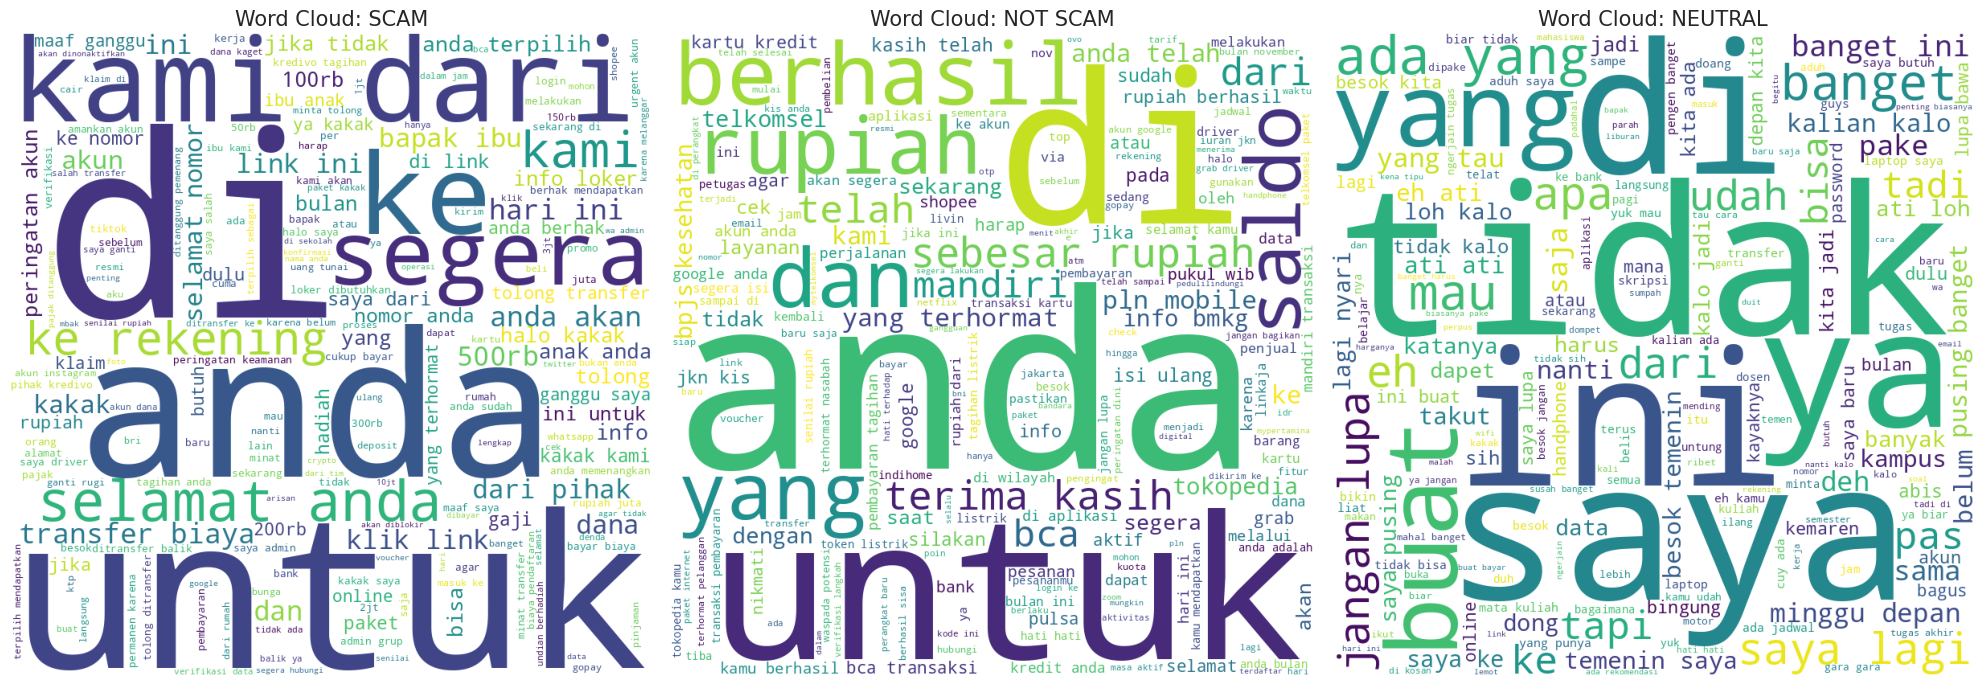

In [7]:
perform_comprehensive_eda(df)

In [8]:
slang_dict = {
    # Kata ganti orang
    'gue': 'saya', 'gw': 'saya', 'ane': 'saya', 'aku': 'saya',
    'lo': 'kamu', 'lu': 'kamu', 'elu': 'kamu', 'ente': 'kamu',
    'dia': 'dia', 'dy': 'dia',

    # Kata sapaan
    'bro': 'kakak', 'sis': 'kakak', 'sist': 'kakak', 'gan': 'kakak',
    'kak': 'kakak', 'mba': 'mbak', 'mas': 'mas', 'pak': 'bapak', 'bu': 'ibu',
    'bpk': 'bapak', 'bp': 'bapak', 'ibu': 'ibu', 'ayah': 'ayah', 'bunda': 'ibu',

    # Singkatan umum
    'yg': 'yang', 'sy': 'saya', 'dg': 'dengan', 'dgn': 'dengan',
    'utk': 'untuk', 'tdk': 'tidak', 'tdk': 'tidak', 'blm': 'belum',
    'sdh': 'sudah', 'tgl': 'tanggal', 'bln': 'bulan', 'thn': 'tahun',
    'krn': 'karena', 'krna': 'karena', 'karna': 'karena',
    'jd': 'jadi', 'jdi': 'jadi', 'jg': 'juga', 'jga': 'juga',
    'sm': 'sama', 'dr': 'dari', 'pd': 'pada', 'ke': 'ke',
    'dlm': 'dalam', 'spt': 'seperti', 'hrs': 'harus',
    'u/': 'untuk', 'dr': 'dari', 'bg': 'bagi',

    # Kata kerja
    'lg': 'lagi', 'lgi': 'lagi', 'lgs': 'langsung', 'lgsg': 'langsung',
    'bgt': 'banget', 'bngt': 'banget', 'bgt': 'banget',
    'bs': 'bisa', 'bisa': 'bisa', 'ga': 'tidak', 'gak': 'tidak', 'engga': 'tidak',
    'gk': 'tidak', 'nggak': 'tidak', 'kagak': 'tidak',
    'tlg': 'tolong', 'tlong': 'tolong', 'tolong': 'tolong',
    'tlp': 'telepon', 'telp': 'telepon', 'hp': 'handphone',
    'hub': 'hubungi', 'kontak': 'hubungi',
    'ama': 'sama', 'sm': 'sama',

    # Kata sifat
    'bgt': 'banget', 'bgt': 'sekali', 'bener': 'benar', 'bnr': 'benar',
    'byk': 'banyak', 'bnyk': 'banyak', 'dikit': 'sedikit', 'dkt': 'dekat',
    'jauh': 'jauh', 'dkt': 'dekat',

    # Kata tanya
    'gmn': 'bagaimana', 'gimana': 'bagaimana', 'gmana': 'bagaimana',
    'knp': 'kenapa', 'knapa': 'kenapa', 'napa': 'kenapa', 'ngapain': 'mengapa',
    'dmn': 'dimana', 'dmana': 'dimana', 'mana': 'mana',
    'kpn': 'kapan', 'kapan': 'kapan',

    # Kata waktu
    'skrg': 'sekarang', 'skrang': 'sekarang', 'skg': 'sekarang',
    'ntar': 'nanti', 'ntr': 'nanti', 'nanti': 'nanti',
    'kmrn': 'kemarin', 'kemaren': 'kemarin', 'kmren': 'kemarin',
    'bsk': 'besok', 'besok': 'besok',

    # Kata tempat
    'rmh': 'rumah', 'rumah': 'rumah', 'tmp': 'tempat', 'tmpt': 'tempat',

    # Kata penting untuk fraud
    'trm': 'terima', 'trf': 'transfer', 'kirim': 'kirim', 'krm': 'kirim',
    'rek': 'rekening', 'norek': 'nomor rekening', 'nmr': 'nomor',
    'no': 'nomor', 'akun': 'akun', 'acc': 'akun',
    'pw': 'password', 'pass': 'password', 'sandi': 'password',
    'link': 'link', 'tautan': 'link', 'url': 'link',
    'klik': 'klik', 'klik': 'klik',
    'segera': 'segera', 'sgr': 'segera', 'cpt': 'cepat', 'cpat': 'cepat',
    'untung': 'untung', 'menang': 'menang', 'hadiah': 'hadiah',
    'gratis': 'gratis', 'free': 'gratis', 'promo': 'promosi',
    'bonus': 'bonus', 'diskon': 'diskon',

    # Singkatan finansial
    'rp': 'rupiah', 'jt': 'juta', 'juta': 'juta', 'rb': 'ribu', 'ribu': 'ribu',
    'jutaan': 'juta', 'ribuan': 'ribu', 'milyar': 'miliar', 'miliar': 'miliar',

    # Kata penghubung
    'tp': 'tapi', 'tpi': 'tapi', 'tp': 'tetapi',
    'kl': 'kalau', 'klo': 'kalau', 'klau': 'kalau',
    'krn': 'karena', 'soalnya': 'karena', 'soale': 'karena',

    # Partikel
    'aja': 'saja', 'aj': 'saja', 'sih': 'sih', 'deh': 'lah', 'dong': 'dong',
    'nih': 'ini', 'tuh': 'itu', 'kek': 'seperti', 'kayak': 'seperti',

    # Kata seruan
    'wkwk': '', 'wkwkwk': '', 'haha': '', 'hehe': '', 'hihi': '',
    'wah': 'wah', 'aduh': 'aduh', 'waduh': 'waduh', 'astaga': 'astaga',

    # Kata informal lainnya
    'emg': 'memang', 'emang': 'memang', 'emng': 'memang',
    'tau': 'tahu', 'taw': 'tahu', 'kaga': 'tidak',
    'org': 'orang', 'orng': 'orang', 'orang': 'orang',
    'gitu': 'begitu', 'gt': 'begitu', 'gtu': 'begitu',
    'nih': 'ini', 'ni': 'ini', 'neh': 'ini',
    'jgn': 'jangan', 'jangan': 'jangan', 'jan': 'jangan',

    # Singkatan lembaga (untuk konteks fraud)
    'atm': 'atm', 'bri': 'bri', 'bca': 'bca', 'bni': 'bni', 'mandiri': 'mandiri',
    'gopay': 'gopay', 'ovo': 'ovo', 'dana': 'dana', 'shopeepay': 'shopeepay',
    'shopee': 'shopee', 'tokopedia': 'tokopedia', 'lazada': 'lazada',
    'whatsapp': 'whatsapp', 'wa': 'whatsapp', 'instagram': 'instagram', 'ig': 'instagram',
    'facebook': 'facebook', 'fb': 'facebook',

    # Tambahan kata-kata yang sering muncul
    'yth': 'yang terhormat', 'sdr': 'saudara', 'sdri': 'saudari',
    'a/n': 'atas nama', 'an': 'atas nama',
}

print(f"✓ Kamus normalisasi berisi {len(slang_dict)} kata/frasa")
print("\nSample kamus normalisasi:")
sample_items = list(slang_dict.items())[:10]
for key, value in sample_items:
    print(f"  '{key}' → '{value}'")

def clean_text(text, remove_url=True, remove_phone=True, remove_numbers=False,
               normalize_slang=True, remove_emoji=True, lowercase=True):

    if not isinstance(text, str):
        return ""

    # 1. Remove URL
    if remove_url:
        # Hapus berbagai format URL
        text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ', text)
        text = re.sub(r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ', text)
        text = re.sub(r'bit\.ly/\S+', ' ', text)
        text = re.sub(r's\.id/\S+', ' ', text)
        # Hapus pattern domain
        text = re.sub(r'\w+\.(com|net|org|info|xyz|id|web\.id)\S*', ' ', text)

    # 2. Remove phone numbers
    if remove_phone:
        # Format Indonesia: 08xx, +628xx, 1500xxx
        text = re.sub(r'\+?62\s?8[0-9]{8,11}', ' ', text)
        text = re.sub(r'\b08[0-9]{8,11}\b', ' ', text)
        text = re.sub(r'\b1500[0-9]{3}\b', ' ', text)
        # Format dengan xxx (tersensor)
        text = re.sub(r'08[0-9]{1,2}x+', ' ', text)
        text = re.sub(r'\b[0-9]{3,4}x+', ' ', text)

    # 3. Remove emoji
    if remove_emoji:
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r' ', text)

    # 4. Normalize whitespace dan karakter khusus
    text = re.sub(r'\s+', ' ', text)  # Multiple spaces jadi satu
    text = re.sub(r'[^\w\s]', ' ', text)  # Hapus punctuation kecuali underscore

    # 5. Convert to lowercase (sebelum normalisasi agar matching lebih baik)
    if lowercase:
        text = text.lower()

    # 6. Normalize slang words
    if normalize_slang:
        words = text.split()
        normalized_words = []
        for word in words:
            # Cek di kamus, jika ada gunakan normalisasi, jika tidak pakai asli
            normalized_word = slang_dict.get(word, word)
            if normalized_word:  # Jika bukan string kosong
                normalized_words.append(normalized_word)
        text = ' '.join(normalized_words)

    # 7. Remove extra spaces lagi setelah normalisasi
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Optional: Remove numbers (jika diminta)
    if remove_numbers:
        text = re.sub(r'\d+', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()

    return text

✓ Kamus normalisasi berisi 211 kata/frasa

Sample kamus normalisasi:
  'gue' → 'saya'
  'gw' → 'saya'
  'ane' → 'saya'
  'aku' → 'saya'
  'lo' → 'kamu'
  'lu' → 'kamu'
  'elu' → 'kamu'
  'ente' → 'kamu'
  'dia' → 'dia'
  'dy' → 'dia'


In [9]:
# Prepare labels
label_map = {'not scam': 0, 'neutral': 1, 'scam': 2}
id2label = {0: 'not scam', 1: 'neutral', 2: 'scam'}
label2id = {'not scam': 0, 'neutral': 1, 'scam': 2}
df['label_id'] = df['label'].map(label_map)

# Split: 70% train, 15% val, 15% test
X = df['text_cleaned']
y = df['label_id']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Train: 1052 | Val: 225 | Test: 226


## SECTION 3: IndoBERT Model

In [10]:
# Load IndoBERT
model_name = 'indobenchmark/indobert-base-p1'
print(f'Loading {model_name}...')
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3, id2label=id2label, label2id=label2id
)
print('✓ Model loaded')

Loading indobenchmark/indobert-base-p1...


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded


In [11]:
# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
val_dataset = Dataset.from_dict({'text': X_val.tolist(), 'label': y_val.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
print('✓ Tokenization complete')

Map:   0%|          | 0/1052 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Map:   0%|          | 0/225 [00:00<?, ? examples/s]

Map:   0%|          | 0/226 [00:00<?, ? examples/s]

✓ Tokenization complete


In [12]:
# Define metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

In [13]:
# Training configuration
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    logging_steps=50,
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='steps',
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    push_to_hub=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)
print('Trainer ready!')

Trainer ready!


In [14]:
# Train model
print('='*60)
print('STARTING TRAINING')
print('='*60)
trainer.train()
print('\n✓ Training complete!')

STARTING TRAINING


wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rizqikapratamaa (rizqikapratamaa-institut-teknologi-bandung) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
100,0.135100,0.042507,0.995556,0.995465,0.995495,0.995495
200,0.004800,0.014215,0.995556,0.995578,0.995781,0.995434
300,0.000900,0.027732,0.995556,0.995465,0.995495,0.995495



✓ Training complete!


## SECTION 4: Evaluation

In [15]:
# Evaluate
results = trainer.evaluate(test_dataset)
print('\nTEST SET RESULTS:')
for key, value in results.items():
    if 'loss' not in key:
        print(f'{key}: {value:.4f}')


TEST SET RESULTS:
eval_accuracy: 0.9823
eval_f1: 0.9820
eval_precision: 0.9820
eval_recall: 0.9820
eval_runtime: 1.5994
eval_samples_per_second: 141.3040
eval_steps_per_second: 5.0020
epoch: 5.0000


In [16]:
# Get predictions
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)
y_true = predictions.label_ids

# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['not scam', 'neutral', 'scam']))


Classification Report:
              precision    recall  f1-score   support

    not scam       0.97      0.97      0.97        75
     neutral       1.00      1.00      1.00        78
        scam       0.97      0.97      0.97        73

    accuracy                           0.98       226
   macro avg       0.98      0.98      0.98       226
weighted avg       0.98      0.98      0.98       226



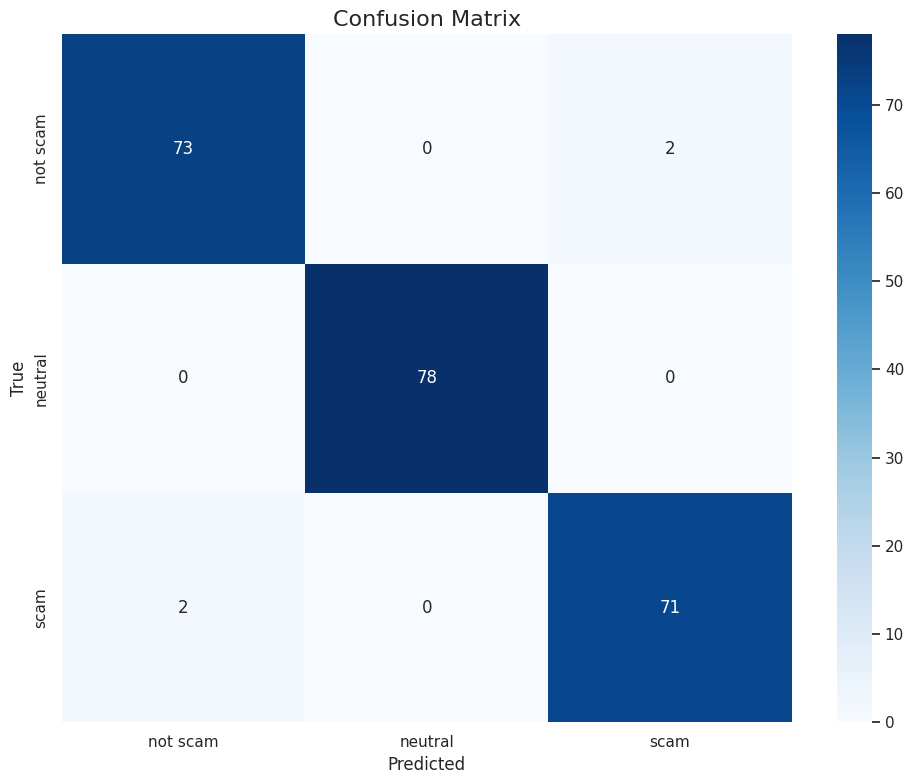

In [17]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not scam', 'neutral', 'scam'],
            yticklabels=['not scam', 'neutral', 'scam'])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## SECTION 5: Save Model


In [18]:
# Save model
save_dir = './fraud_detection_indobert'
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'✓ Model saved to {save_dir}')

✓ Model saved to ./fraud_detection_indobert


In [19]:
import shutil
import os

# Create destination folder in Google Drive
gdrive_path = '/content/drive/MyDrive/NLP_Models/fraud_detection_indobert'
os.makedirs(os.path.dirname(gdrive_path), exist_ok=True)

# Copy the model folder
print('Copying model to Google Drive...')
shutil.copytree('./fraud_detection_indobert', gdrive_path, dirs_exist_ok=True)
print(f'✓ Model uploaded to Google Drive!')
print(f'✓ Location: MyDrive/NLP_Models/fraud_detection_indobert_1')

Copying model to Google Drive...
✓ Model uploaded to Google Drive!
✓ Location: MyDrive/NLP_Models/fraud_detection_indobert_1


## SECTION 6: Predicion

In [20]:
# Prediction function
def predict_fraud(text, return_proba=False):
    text_cleaned = clean_text(text)
    inputs = tokenizer(text_cleaned, return_tensors='pt', padding='max_length',
                      truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    prediction = id2label[pred_id]
    confidence = probs[pred_id].item()
    if return_proba:
        probabilities = {id2label[i]: probs[i].item() for i in range(len(probs))}
        return prediction, confidence, probabilities
    return prediction, confidence

model.to(device)
print('✓ Prediction function ready!')

✓ Prediction function ready!


In [21]:
# Test prediction
test_texts = [
    'Selamat! Anda menang hadiah 10 juta. Klik link ini.',
    'Shopee: Paket Anda sudah sampai di hub terdekat.',
    'Gue lagi cari laptop buat kuliah nih.'
]

for text in test_texts:
    pred, conf, probs = predict_fraud(text, return_proba=True)
    print(f'\nText: {text}')
    print(f'Prediction: {pred.upper()} ({conf:.2%})')
    print(f'Probabilities: {probs}')


Text: Selamat! Anda menang hadiah 10 juta. Klik link ini.
Prediction: SCAM (97.91%)
Probabilities: {'not scam': 0.008937706239521503, 'neutral': 0.011974860914051533, 'scam': 0.9790874719619751}

Text: Shopee: Paket Anda sudah sampai di hub terdekat.
Prediction: NOT SCAM (99.92%)
Probabilities: {'not scam': 0.9991632699966431, 'neutral': 0.0005964332958683372, 'scam': 0.00024040858261287212}

Text: Gue lagi cari laptop buat kuliah nih.
Prediction: NEUTRAL (99.87%)
Probabilities: {'not scam': 0.0010489689884707332, 'neutral': 0.9987106323242188, 'scam': 0.00024037093680817634}


# xAi

In [22]:
!pip install lime indoNLP transformers torch -q

# Mount Google Drive to access the saved model
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import re
import torch
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from indoNLP.preprocessing import replace_slang

# Clear GPU memory to avoid OOM errors
torch.cuda.empty_cache()
gc.collect()

# Load the saved fraud detection model from Google Drive
model_path = '/content/drive/MyDrive/NLP_Models/fraud_detection_indobert'
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path, output_hidden_states=True)

# Use CPU for LIME (GPU causes OOM with many perturbations)
device = torch.device('cpu')
model.to(device)
model.eval()

print(f'Model loaded from Google Drive')
print(f'Path: {model_path}')
print(f'Using device: {device} (CPU mode - prevents OOM with LIME)')
print(f'Ready for xAI explanations!')

Model loaded from Google Drive
Path: /content/drive/MyDrive/NLP_Models/fraud_detection_indobert
Using device: cpu (CPU mode - prevents OOM with LIME)
Ready for xAI explanations!


In [ ]:
from lime.lime_text import LimeTextExplainer
import numpy as np

class FraudClassifierForXAI:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()

    def predict_proba(self, texts):
        '''Required format for LIME - with batch processing to save memory'''
        texts_cleaned = [clean_text(text) for text in texts]

        batch_size = 32  # reduced from default
        all_probs = []

        for i in range(0, len(texts_cleaned), batch_size):
            batch = texts_cleaned[i:i + batch_size]
            inputs = self.tokenizer(batch, return_tensors='pt',
                                   padding='max_length', truncation=True, max_length=128)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = self.model(**inputs)
                probs = torch.softmax(outputs.logits, dim=-1)

            all_probs.append(probs.cpu().numpy())

            # clear cache after each batch
            del inputs, outputs, probs
            if self.device.type == 'cuda':
                torch.cuda.empty_cache()

        return np.vstack(all_probs)

fraud_classifier_xai = FraudClassifierForXAI(model, tokenizer, device)

class FraudReasoningXAI:
    def __init__(self, classifier_pipeline, tokenizer, class_names=['not scam', 'neutral', 'scam']):
        self.classifier_pipeline = classifier_pipeline
        self.tokenizer = tokenizer
        self.class_names = class_names
        self.explainer = LimeTextExplainer(class_names=class_names)

    def _predict_proba_wrapper(self, texts):
        return fraud_classifier_xai.predict_proba(texts)

    def explain_text(self, text_input, num_features=5, num_samples=5000):
        # generate explanation menggunakan LIME with reduced samples
        exp = self.explainer.explain_instance(
            text_input,
            self._predict_proba_wrapper,
            num_features=num_features,
            num_samples=num_samples,
            top_labels=1
        )

        top_label_idx = exp.top_labels[0]
        predicted_label = self.class_names[top_label_idx]

        explanation_list = exp.as_list(label=top_label_idx)
        keywords = [word for word, weight in explanation_list if weight > 0]

        return self._generate_natural_language_reasoning(predicted_label, keywords, text_input)

    def _generate_natural_language_reasoning(self, label, keywords, original_text):
        if not keywords:
            return f"Sistem mengklasifikasikan pesan ini sebagai **{label.upper()}**, namun pola spesifik sulit ditentukan secara individu."

        keywords_str = ", ".join([f"'{k}'" for k in keywords])

        reasoning = ""
        if label == 'scam':
            reasoning = (
                f"Pesan terdeteksi sebagai **SCAM**. \n"
                f"**Analisis:** Sistem menemukan indikasi penipuan kuat berdasarkan penggunaan kata kunci: **{keywords_str}**. \n"
                f"Kata-kata ini sering muncul dalam pola penipuan (seperti permintaan uang, urgensi, atau hadiah palsu) pada dataset historis."
            )
        elif label == 'neutral':
            reasoning = (
                f"Pesan dikategorikan **NETRAL**. \n"
                f"Meskipun mengandung kata **{keywords_str}**, konteksnya tidak cukup kuat untuk dianggap sebagai penipuan atau pesan resmi yang valid."
            )
        else: # Not Scam / Info Resmi
            reasoning = (
                f"Pesan ini diklasifikasikan **AMAN (Not Scam)**. \n"
                f"Struktur kalimat dan kata kunci seperti **{keywords_str}** konsisten dengan format informasi atau komunikasi wajar."
            )

        return reasoning

# Inisialisasi Explainer
xai_module = FraudReasoningXAI(
    classifier_pipeline=fraud_classifier_xai.predict_proba,
    tokenizer=tokenizer
)

# Teks Query (Contoh kasus)
query_text = "Halo Kak, kami dari admin grup 'Info Crypto Valid'. Anda harus bayar biaya langganan bulanan 200rb untuk tetap dapat info coin yang bakal pump."

print("Generating LIME explanation (this may take 30-60 seconds on CPU)...")

# Jalankan Reasoning with optimized parameters
reasoning_output = xai_module.explain_text(query_text, num_features=5, num_samples=10)

print("="*50)
print("HASIL TEST xAI REASONING")
print("="*50)
print(f"Input Text: {query_text}\n")
print(reasoning_output)

Generating LIME explanation (this may take 30-60 seconds on CPU)...
HASIL TEST xAI REASONING
Input Text: Halo Kak, kami dari admin grup 'Info Crypto Valid'. Anda harus bayar biaya langganan bulanan 200rb untuk tetap dapat info coin yang bakal pump.

Pesan terdeteksi sebagai **SCAM**. 
**Analisis:** Sistem menemukan indikasi penipuan kuat berdasarkan penggunaan kata kunci: **'pump', 'Halo', 'Anda', 'bayar', 'info'**. 
Kata-kata ini sering muncul dalam pola penipuan (seperti permintaan uang, urgensi, atau hadiah palsu) pada dataset historis.


# Text Similarity

In [25]:
fraud_df = pd.read_csv('https://drive.google.com/uc?id=1c50z3TtNR4DRHCjz4vsPvV6pYnnsem4V')
fraud_data = fraud_df[fraud_df['label'] == 'scam']
print(f"Loaded {len(fraud_data)} scam examples")

Loaded 654 scam examples


In [26]:
class SimilarityMatcher:
    def __init__(self, fraud_data, model, tokenizer):
        self.fraud_data = fraud_data
        self.model = model
        self.tokenizer = tokenizer
        self.fraud_texts = fraud_data['text'].fillna('').tolist()
        self.fraud_embeddings = self._get_embeddings_batch(self.fraud_texts)

    def _get_embeddings_batch(self, texts, batch_size=32):
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            embeddings = self._get_embeddings(batch)
            all_embeddings.append(embeddings)
        return np.vstack(all_embeddings)

    def _get_embeddings(self, texts):
        if isinstance(texts, str):
            texts = [texts]
        encoded_input = self.tokenizer(texts, padding=True, truncation=True,
                                       max_length=512, return_tensors='pt')
        encoded_input = {k: v.to(device) for k, v in encoded_input.items()}
        with torch.no_grad():
            model_output = self.model(**encoded_input)
        attention_mask = encoded_input['attention_mask']
        # Access the last hidden state from the hidden_states tuple
        token_embeddings = model_output.hidden_states[-1]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        embeddings = torch.sum(token_embeddings * input_mask_expanded, 1) / \
                    torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        return embeddings.cpu().numpy()

    def find_similar(self, text, top_k=3):
        from sklearn.metrics.pairwise import cosine_similarity
        input_embedding = self._get_embeddings([text])
        similarities = cosine_similarity(input_embedding, self.fraud_embeddings)[0]
        top_indices = similarities.argsort()[::-1][:top_k]
        results = []
        for idx in top_indices:
            results.append({
                'text': self.fraud_texts[idx],
                'similarity': float(similarities[idx])
            })
        return results

similarity_matcher = SimilarityMatcher(fraud_data, model, tokenizer)
print("Similarity matcher ready!")

Similarity matcher ready!


In [27]:
def predict_fraud_enhanced(text, return_proba=False, include_similarity=True):
    # Classification
    text_cleaned = clean_text(text)
    inputs = tokenizer(text_cleaned, return_tensors='pt', padding='max_length',
                      truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]

    pred_id = probs.argmax().item()
    label = id2label[pred_id]
    confidence = probs[pred_id].item()

    # Similarity
    similarity_info = None
    if include_similarity:
        similar = similarity_matcher.find_similar(text, top_k=3)
        similarity_info = {
            'most_similar': similar[0],
            'all_similar': similar
        }

    if return_proba:
        probabilities = {id2label[i]: probs[i].item() for i in range(len(probs))}
        return label, confidence, probabilities, similarity_info

    return label, confidence, similarity_info

print("Enhanced prediction ready!")

Enhanced prediction ready!


In [28]:
def analyze_fraud_complete(text):
    print("="*70)
    print("COMPLETE FRAUD ANALYSIS")
    print("="*70)
    print(f"\nMessage:\n{text}\n")

    # Get all predictions
    label, conf, probs, sim = predict_fraud_enhanced(text, return_proba=True)
    # Reduced num_samples for faster explanation generation
    xai_result = xai_module.explain_text(text, num_features=5, num_samples=50)

    # Verdict
    print("="*70)
    if label == 'scam' and sim['most_similar']['similarity'] > 0.85:
        print("VERDICT: HIGH RISK SCAM")
        print(f"   Confidence: {conf:.1%} | Reliability: VERY HIGH")
    elif label == 'scam':
        print("VERDICT: LIKELY SCAM")
        print(f"   Confidence: {conf:.1%} | Reliability: HIGH")
    else:
        print(f"VERDICT: {label.upper()}")
        print(f"   Confidence: {conf:.1%}")
    print("="*70)

    # Classification
    print(f"\n1. CLASSIFICATION:")
    print(f"   Prediction: {label.upper()} ({conf:.1%})")
    print(f"   Probabilities:")
    for lbl, p in sorted(probs.items(), key=lambda x: x[1], reverse=True):
        bar = "-" * int(p * 20)
        print(f"      {lbl:12s}: {p:6.1%} {bar}")

    # Similarity
    print(f"\n2. SIMILARITY ANALYSIS:")
    most_sim = sim['most_similar']
    print(f"   Similarity Score: {most_sim['similarity']:.1%}")
    print(f"   Most Similar Scam:")
    print(f"   \"{most_sim['text'][:80]}...\"")

    if label == 'scam' and most_sim['similarity'] > 0.75:
        print(f"\n   Both classification and similarity agree: SCAM")
    elif label == 'not scam' and most_sim['similarity'] < 0.60:
        print(f"\n   Both methods agree: NOT SCAM")
    else:
        print(f"\n   Mixed signals - manual review recommended")

    # xAI
    print(f"\n3. EXPLAINABLE AI:")
    print(f"   {xai_result}")

    print("\n" + "="*70)

print("Complete analysis ready!")

Complete analysis ready!


In [34]:
# Test case 1
analyze_fraud_complete("Selamat! Anda menang hadiah 10 juta. Klik link ini.")

print("\n" + "="*70 + "\n")

# Test case 2
analyze_fraud_complete("Shopee: Paket sudah sampai di hub Jakarta")

COMPLETE FRAUD ANALYSIS

Message:
Selamat! Anda menang hadiah 10 juta. Klik link ini.

VERDICT: LIKELY SCAM
   Confidence: 97.9% | Reliability: HIGH

1. CLASSIFICATION:
   Prediction: SCAM (97.9%)
   Probabilities:
      scam        :  97.9% -------------------
      neutral     :   1.2% 
      not scam    :   0.9% 

2. SIMILARITY ANALYSIS:
   Similarity Score: 76.3%
   Most Similar Scam:
   "Dana Kaget 1 Juta Rupiah! Siapa cepat dia dapat. Klik link ini sebelum kuota hab..."

   Both classification and similarity agree: SCAM

3. EXPLAINABLE AI:
   Pesan terdeteksi sebagai **SCAM**. 
**Analisis:** Sistem menemukan indikasi penipuan kuat berdasarkan penggunaan kata kunci: **'link', 'Anda', 'hadiah', 'juta', 'Klik'**. 
Kata-kata ini sering muncul dalam pola penipuan (seperti permintaan uang, urgensi, atau hadiah palsu) pada dataset historis.



COMPLETE FRAUD ANALYSIS

Message:
Shopee: Paket sudah sampai di hub Jakarta

VERDICT: NOT SCAM
   Confidence: 99.9%

1. CLASSIFICATION:
   Predic

# Test with Custom Input

Use the cell below to enter any text you want to analyze for fraud. The system will then perform a complete fraud analysis, including classification, similarity, and explainable AI.

In [35]:
user_input_text = input("Masukkan teks yang ingin Anda analisis untuk penipuan: ")

if user_input_text:
    analyze_fraud_complete(user_input_text)
else:
    print("Teks tidak boleh kosong. Silakan masukkan teks untuk dianalisis.")

Masukkan teks yang ingin Anda analisis untuk penipuan: Selamat! Anda menang hadiah 100 juta. Klik link ini.
COMPLETE FRAUD ANALYSIS

Message:
Selamat! Anda menang hadiah 100 juta. Klik link ini.

VERDICT: LIKELY SCAM
   Confidence: 98.5% | Reliability: HIGH

1. CLASSIFICATION:
   Prediction: SCAM (98.5%)
   Probabilities:
      scam        :  98.5% -------------------
      neutral     :   0.9% 
      not scam    :   0.6% 

2. SIMILARITY ANALYSIS:
   Similarity Score: 77.1%
   Most Similar Scam:
   "Dana Kaget 1 Juta Rupiah! Siapa cepat dia dapat. Klik link ini sebelum kuota hab..."

   Both classification and similarity agree: SCAM

3. EXPLAINABLE AI:
   Pesan terdeteksi sebagai **SCAM**. 
**Analisis:** Sistem menemukan indikasi penipuan kuat berdasarkan penggunaan kata kunci: **'link', 'Klik', 'menang', 'hadiah', 'Anda'**. 
Kata-kata ini sering muncul dalam pola penipuan (seperti permintaan uang, urgensi, atau hadiah palsu) pada dataset historis.

